# 01. Exploratory Data Analysis & Business Discovery

**Objective**: Understand the structural integrity of the dataset, evaluate customer demographics and behavioral patterns against churn (`Exited`), check distributions and statistical boundaries across every raw attribute, identify outlier profiles, and establish domain-driven hypotheses for downstream feature engineering.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Data Loading & Initial Health Check

In [2]:
df = pd.read_csv("data/Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Drop administrative identifiers that carry zero generalizable pattern
df1 = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df1.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df1.shape

(10000, 11)

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [8]:
df1.duplicated().sum()

0

In [9]:
df1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df1["Geography"].nunique()

3

In [12]:
df1["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

## 2. Target Variable Analysis (Class Imbalance)

In [13]:
df1['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
df1['Exited'].value_counts(normalize=True).round(2)

Exited
0    0.8
1    0.2
Name: proportion, dtype: float64

> **Key Takeaway**: The dataset exhibits an **80:20 class imbalance** (80% retained, 20% churned). A naive baseline model predicting "retained" for everyone would achieve 80% accuracy but miss 100% of churners. Subsequent modeling must prioritize **F1-Score**, **Precision**, **Recall**, and **ROC-AUC** over raw accuracy.

## 3. Univariate Distribution & Outlier Detection across All 5 Numeric Features

In [15]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

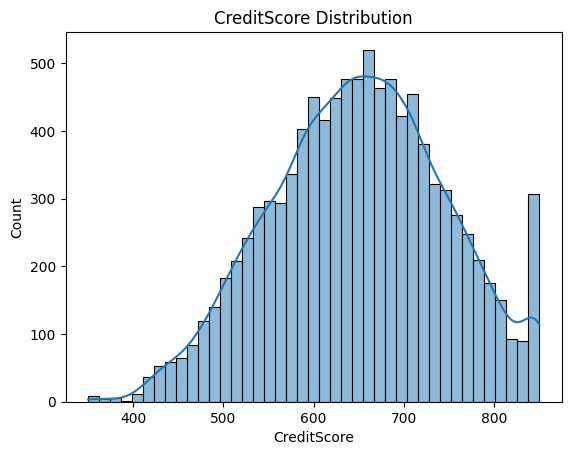

In [16]:
sns.histplot(df1['CreditScore'], kde=True)
plt.title("CreditScore Distribution")
plt.show()

In [17]:
df1['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [18]:
# CreditScore outliers — investigating low credit regions (< 400) via IQR
Q1 = df1['CreditScore'].quantile(0.25)
Q3 = df1['CreditScore'].quantile(0.75)
IQR = Q3 - Q1
low_score_outliers = df1[df1['CreditScore'] < Q1 - 1.5 * IQR]
print("Low CreditScore Outliers Count:", low_score_outliers.shape)

Low CreditScore Outliers Count: (15, 11)


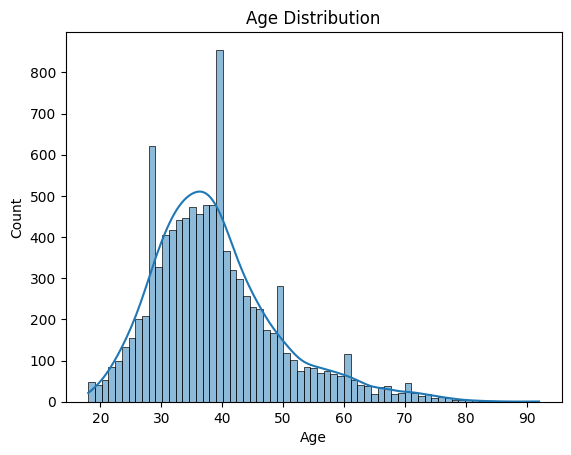

In [19]:
sns.histplot(df1["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

In [20]:
print(df1['Age'].describe())

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


In [21]:
print(df1['Age'].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

0.01    21.0
0.05    25.0
0.50    37.0
0.95    60.0
0.99    72.0
Name: Age, dtype: float64


In [22]:
# Age outliers — checking senior customer distributions via IQR
Q1_age = df1['Age'].quantile(0.25)
Q3_age = df1['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
outliers_age = df1[(df1['Age'] < Q1_age - 1.5 * IQR_age) | (df1['Age'] > Q3_age + 1.5 * IQR_age)]
print("Senior Age Outliers Count:", outliers_age.shape)

Senior Age Outliers Count: (359, 11)


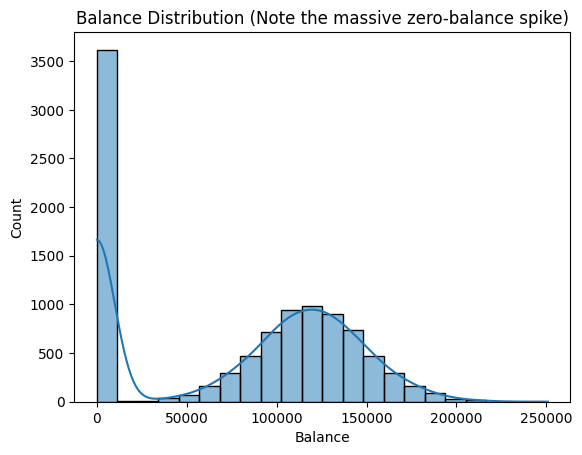

In [23]:
sns.histplot(df1['Balance'], kde=True)
plt.title("Balance Distribution (Note the massive zero-balance spike)")
plt.show()

In [24]:
print("Zero Balance Customers Shape:", df1[df1["Balance"] == 0].shape)

Zero Balance Customers Shape: (3617, 11)


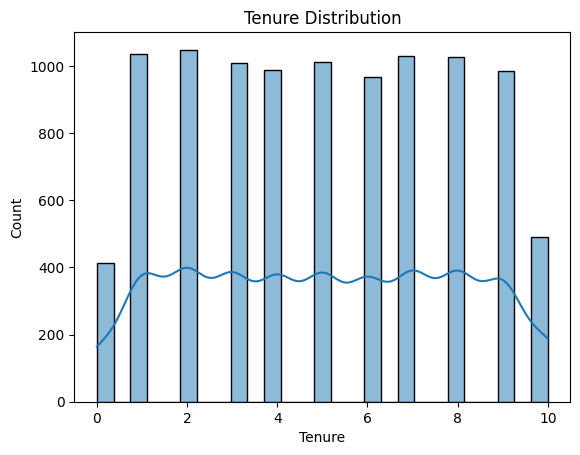

In [25]:
sns.histplot(df1['Tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

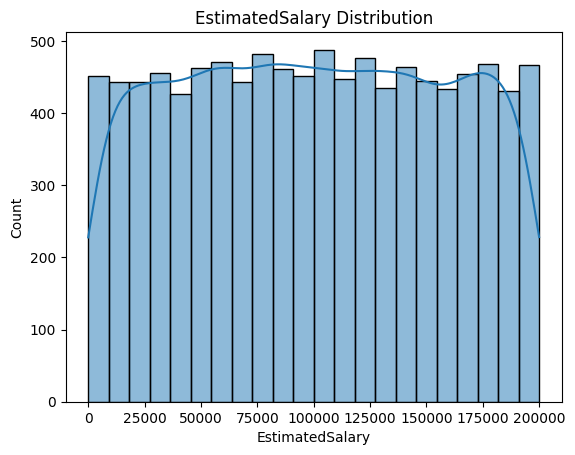

In [26]:
sns.histplot(df1['EstimatedSalary'], kde=True)
plt.title("EstimatedSalary Distribution")
plt.show()

In [27]:
print("Count of Zero Salary Customers:", (df1['EstimatedSalary'] == 0).sum())

Count of Zero Salary Customers: 0


## 4. Bivariate Analysis & Domain Storytelling (vs. Target `Exited`)

### Demographics vs. Churn

In [28]:
df1["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [29]:
df1["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [30]:
df1.groupby("Gender")["Exited"].mean()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [31]:
df1.groupby("Geography")["Exited"].mean()

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [32]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


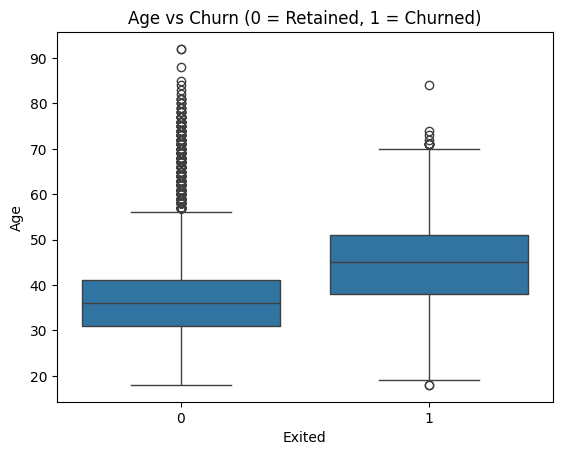

In [33]:
sns.boxplot(x="Exited", y="Age", data=df1)
plt.title("Age vs Churn (0 = Retained, 1 = Churned)")
plt.show()

### Account Behavior vs. Churn

In [34]:
df1.groupby("NumOfProducts")["Exited"].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [35]:
df1.groupby("IsActiveMember")["Exited"].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [36]:
pd.crosstab(df1['NumOfProducts'], df1['IsActiveMember'])

IsActiveMember,0,1
NumOfProducts,,
1,2521,2563
2,2144,2446
3,153,113
4,31,29


## 5. Executive EDA Summary & Hypotheses for Feature Engineering

1. **Zero Balance Flag (`ZeroBalance`)**: 3,617 customers (36.17%) maintain a zero balance. Rather than missing data, this represents a meaningful behavioral cohort (e.g., credit-only users or inactive accounts).
2. **Product Activity Interaction (`ProductActivity`)**: Churn shoots up non-linearly for customers holding 3 products (82.7%) and 4 products (100%). Coupling product volume with member engagement (`NumOfProducts * IsActiveMember`) isolates critical vulnerability segments.
3. **Wealth-to-Income Ratio (`BalanceSalaryRatio`)**: Evaluating a customer's liquid deposit balance relative to their estimated regular salary provides deeper insight into financial stickiness than raw salary alone.
4. **Relative Loyalty Ratio (`TenureAgeRatio`)**: Raw tenure is context-dependent—a 5-year banking relationship means far more for a 26-year-old than for a 65-year-old. Normalizing tenure against customer age reveals true customer stickiness.